In [2]:
import numpy as np
import pickle
import os
import glob
from plyfile import PlyData
import src.utils1 as utils

max_dimension = 3  # Maximum dimension for the simplicial complex
complex_res = {}

# Load sampled datasets
sampled_datasets = {}
for file in glob.glob('datasets/dragon_ply/sampled_*.ply'):
    data = PlyData.read(file)
    points = np.array([list(vertex) for vertex in data['vertex'].data])
    sample = points[:, :3]  # Use only the first three columns (x, y, z)
    sampled_datasets[f"dragon {len(sample)}"] = sample
    print(f"\n--- PROCESSING SAMPLE WITH {len(sample)} POINTS ---")
    complex_res[f"dragon {len(sample)}"] = utils.create_complexes(point_cloud=sample, max_dimension=max_dimension)

# order the complexes by number of points
complex_res = dict(sorted(complex_res.items(), key=lambda item: len(sampled_datasets[item[0]])))
#check order
for name, result in complex_res.items():
    print(f"Complex '{name}' has {len(sampled_datasets[name])} points.")

# Create results directory if it doesn't exist
os.makedirs('results', exist_ok=True)

# Save complex_res to disk
with open('results/dragon_complexes.pkl', 'wb') as f:
    pickle.dump(complex_res, f)
print(f"\nSaved complexes for {len(complex_res)} samples to 'results/dragon_complexes.pkl'")


--- PROCESSING SAMPLE WITH 500 POINTS ---
Analyzing nearest neighbor distance distribution to set adaptive parameters...
  - Rips/Alpha Scale (based on 95th percentile of 1-NN distances):
    Characteristic 1-NN dist = 0.012044
    Edge Length (d) = 0.036132, Radius (r) = 0.018066
  -> Calculating cdist for witness scale...
  -> cdist calculation complete.
  - Witness Scale:    Search Radius = 0.026023 (Derived from 90th percentile of witness-landmark distances)

Using adaptive parameters:
  Rips edge length: 0.036132
  Alpha max value: 0.018066 (alpha²=0.000326)
  Cech max value: 0.018066 (alpha²=0.000326)
  Witness max value: 0.026023 (alpha²=0.000677)
  Strong witness max value: 0.026023 (alpha²=0.000677)

Creating complexes with adaptive parameters...
 -> Processing Rips complex...
 -> Rips complex: 697126 simplices (processed in 0.299s, memory: 44.164 MB)
 -> Processing Alpha complex...
 -> Alpha complex: 9821 simplices (processed in 0.016s, memory: 4.375 MB)
 -> Processing Cech 

In [3]:
utils.print_performance_table(complex_res)


PERFORMANCE SUMMARY TABLE
Sample         Rips              Alpha             Cech              Delaunay Cech     Delaunay Alpha    Witness           Relaxed Witness   Strong Witness    
------------------------------------------------------------------------------------------------------------------------------------------------------------
PROCESSING TIME (s)
------------------------------------------------------------------------------------------------------------------------------------------------------------
dragon 500     0.299             0.016             0.012             0.013             0.016             0.002             0.023             0.003             
dragon 1000    0.646             0.035             0.025             0.027             0.036             0.005             0.032             0.006             
dragon 1501    0.474             0.057             0.040             0.043             0.058             0.010             0.038             0.008             

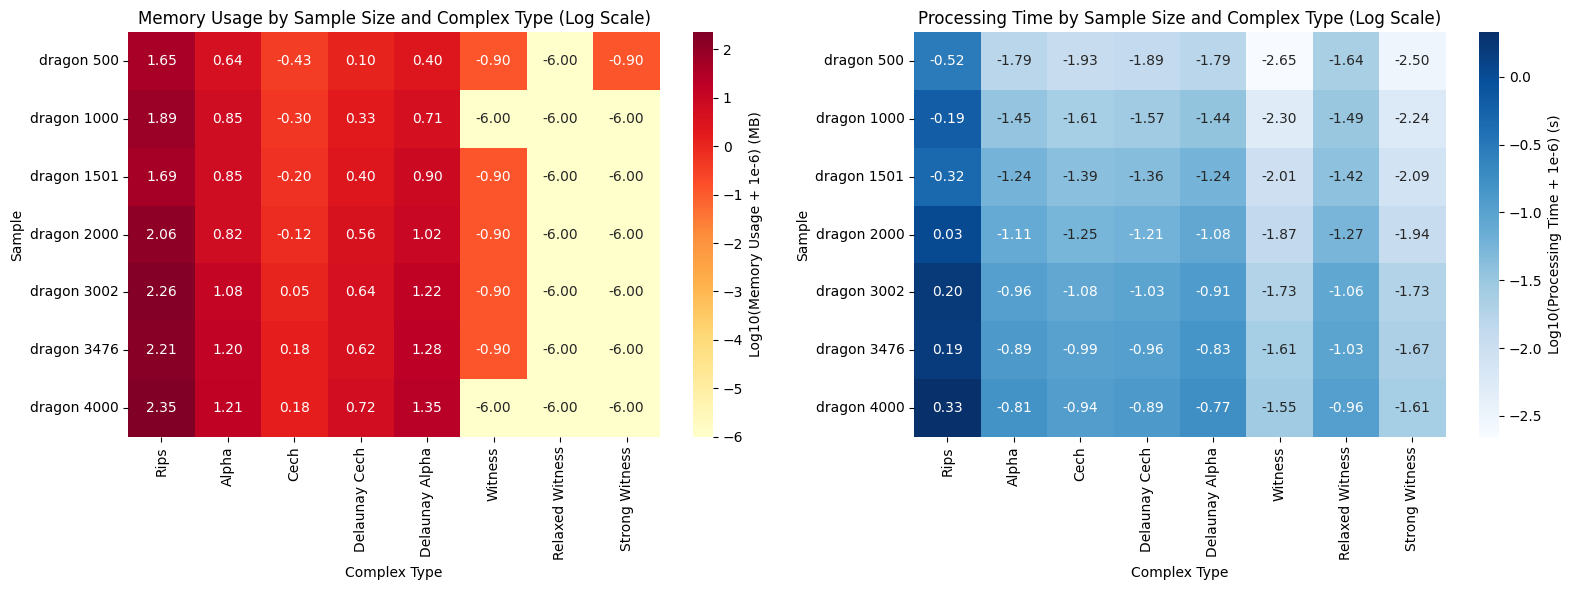


Original Memory Usage Statistics (MB):
             Rips      Alpha      Cech  Delaunay Cech  Delaunay Alpha  \
count    7.000000   7.000000  7.000000       7.000000        7.000000   
mean   121.878348   9.857143  0.910714       3.321429       11.982143   
std     69.297866   4.778657  0.466114       1.412108        7.417051   
min     44.164062   4.375000  0.375000       1.250000        2.500000   
25%     63.367188   6.812500  0.562500       2.312500        6.562500   
50%    116.125000   7.000000  0.750000       3.625000       10.500000   
75%    171.000000  13.875000  1.312500       4.250000       17.750000   
max    224.125000  16.250000  1.500000       5.250000       22.250000   

        Witness  Relaxed Witness  Strong Witness  
count  7.000000              7.0        7.000000  
mean   0.089286              0.0        0.017857  
std    0.060994              0.0        0.047246  
min    0.000000              0.0        0.000000  
25%    0.062500              0.0        0.00000

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract data for heatmaps
sample_names = list(complex_res.keys())
complex_types = list(complex_res[sample_names[0]].keys())

# Create matrices for memory and time data
memory_data = []
time_data = []

for sample in sample_names:
    memory_row = []
    time_row = []
    for complex_type in complex_types:
        memory_row.append(complex_res[sample][complex_type].memory_usage_mb)
        time_row.append(complex_res[sample][complex_type].processing_time_s)
    memory_data.append(memory_row)
    time_data.append(time_row)

# Convert to DataFrames for easier plotting
memory_df = pd.DataFrame(memory_data, 
                        index=sample_names, 
                        columns=[ct.replace('_', ' ').title() for ct in complex_types])
time_df = pd.DataFrame(time_data, 
                      index=sample_names, 
                      columns=[ct.replace('_', ' ').title() for ct in complex_types])

# Apply logarithmic transformation (add small value to avoid log(0))
log_memory_df = np.log10(memory_df + 1e-6)
log_time_df = np.log10(time_df + 1e-6)

# Create heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Memory usage heatmap (logarithmic)
sns.heatmap(log_memory_df, annot=True, fmt='.2f', cmap='YlOrRd', 
            ax=ax1, cbar_kws={'label': 'Log10(Memory Usage + 1e-6) (MB)'})
ax1.set_title('Memory Usage by Sample Size and Complex Type (Log Scale)')
ax1.set_xlabel('Complex Type')
ax1.set_ylabel('Sample')

# Processing time heatmap (logarithmic)
sns.heatmap(log_time_df, annot=True, fmt='.2f', cmap='Blues', 
            ax=ax2, cbar_kws={'label': 'Log10(Processing Time + 1e-6) (s)'})
ax2.set_title('Processing Time by Sample Size and Complex Type (Log Scale)')
ax2.set_xlabel('Complex Type')
ax2.set_ylabel('Sample')

plt.tight_layout()
plt.show()

# Print summary statistics for original and log-transformed data
print("\nOriginal Memory Usage Statistics (MB):")
print(memory_df.describe())
print("\nLog10 Memory Usage Statistics:")
print(log_memory_df.describe())

print("\nOriginal Processing Time Statistics (s):")
print(time_df.describe())
print("\nLog10 Processing Time Statistics:")
print(log_time_df.describe())